## 📌 STEP 1: Import Libraries 

In [56]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

## STEP 2: Load Dataset 

In [14]:
# Step 2: Load the data file using pandas
df = pd.read_csv("googleplaystore.csv")

# Checking the first few rows
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## 📌 STEP 3: Check Null Values 

In [15]:
# Step 3: Check for null values in each column
print(df.isnull().sum())

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


## 📌 STEP 4: Drop Null Values 

In [16]:
# Step 4: Drop records with nulls in any of the columns
df.dropna(inplace=True)
print("Null values after dropping:", df.isnull().sum().sum())

# Check again
df.isnull().sum()

Null values after dropping: 0


App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

## 📌 STEP 5: Data Cleaning

#### 🔹 (A) Size Column Clean

In [17]:
# Step 5(A): Fixing Size column - Convert Kb to Mb and then to numeric
# Remove 'Varies with device'
df = df[df['Size'] != 'Varies with device']

# Convert Size to numeric
def convert_size(size):
    if 'M' in size:
        return float(size.replace('M','')) * 1000
    elif 'k' in size:
        return float(size.replace('k',''))
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)
df.dropna(subset=['Size'], inplace=True)

#### 🔹 (B) Reviews → Numeric

In [18]:
# Step 5(B): Convert Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'])

#### 🔹 (C) Installs Clean

In [19]:
# Step 5(C): Fix Installs - Remove '+' and ',' and convert to int
df['Installs'] = df['Installs'].str.replace('+','')
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = df['Installs'].astype(int)

#### 🔹 (D) Price Clean

In [20]:
# Step 5(D): Fix Price - Remove '$' and convert to numeric
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = df['Price'].astype(float)

#### 🔹 (E) Sanity Checks

In [21]:
# Step 5(E): Sanity Checks
# 1. Rating between 1 and 5
df = df[(df['Rating'] >= 1) & (df['Rating'] <= 5)]

# 2. Reviews should not be more than installs
df = df[df['Reviews'] <= df['Installs']]

# 3. For Free apps, price must be 0
df = df[~((df['Type'] == 'Free') & (df['Price'] > 0))]

## 📊 STEP 6: Univariate Analysis

#### 🔹 Boxplot Price

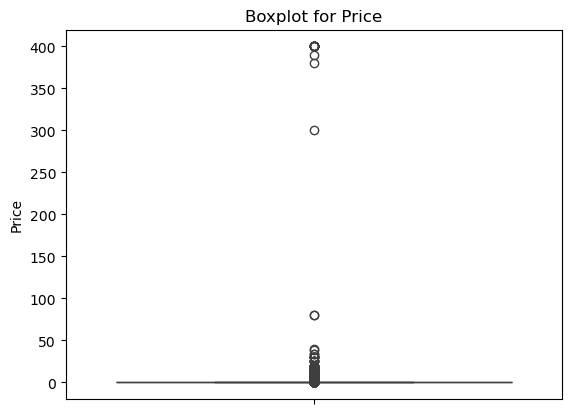

In [22]:
# Boxplot for Price
sns.boxplot(df['Price'])
plt.title("Boxplot for Price")
plt.show()

`Observation: Most apps are free or low priced, few extreme outliers present`

#### 🔹 Boxplot Reviews

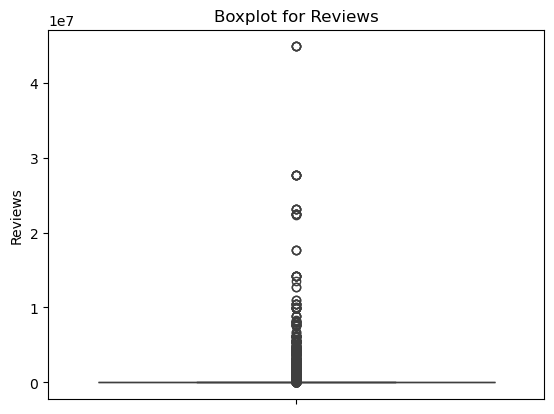

In [23]:
sns.boxplot(df['Reviews'])
plt.title("Boxplot for Reviews")
plt.show()

#### 🔹 Histogram Rating

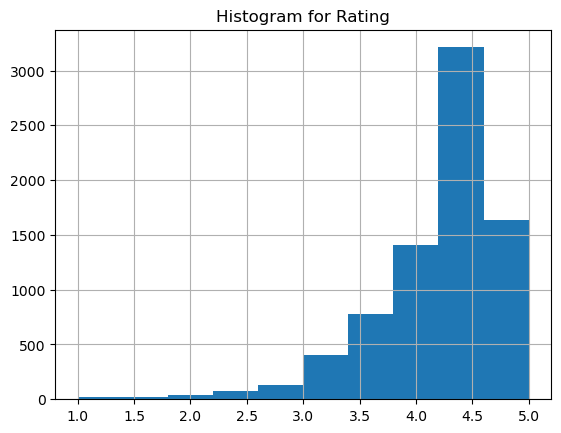

In [24]:
df['Rating'].hist()
plt.title("Histogram for Rating")
plt.show()

#### 🔹 Histogram Size

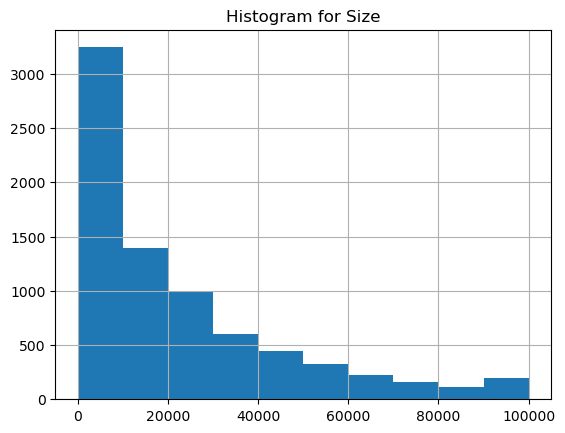

In [25]:
df['Size'].hist()
plt.title("Histogram for Size")
plt.show()

## ⚠️ STEP 7: Outlier Treatment

#### 🔹 Price

In [26]:
# Drop apps with price >= 200 (junk apps)
df = df[df['Price'] <= 200]

#### 🔹 Reviews

In [27]:
# Drop records with more than 2 million reviews
df = df[df['Reviews'] <= 2000000]

#### 🔹 Installs

In [28]:
# Drop high install apps based on percentile (cutoff)
# Finding 95th percentile for Installs
df['Installs'].quantile([0.1,0.25,0.5,0.7,0.9,0.95,0.99])
df = df[df['Installs'] <= df['Installs'].quantile(0.95)]

## 📊 STEP 8: Bivariate Analysis

#### 🔹 Rating vs Price

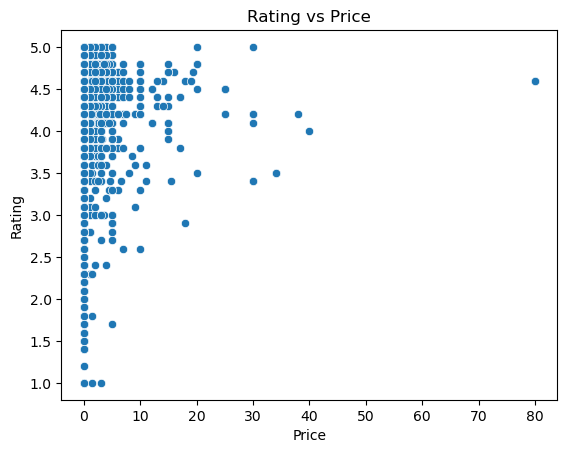

In [32]:
sns.scatterplot(x='Price', y='Rating', data=df)
plt.title("Rating vs Price")
plt.show()

`# Observation: No strong relationship between price and rating`

#### 🔹 Rating vs Size

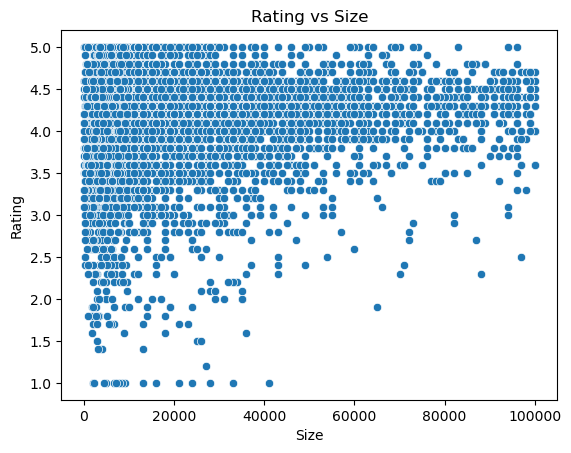

In [34]:
sns.scatterplot(x='Size', y='Rating', data=df)
plt.title("Rating vs Size")
plt.show()

#### 🔹 Rating vs Reviews

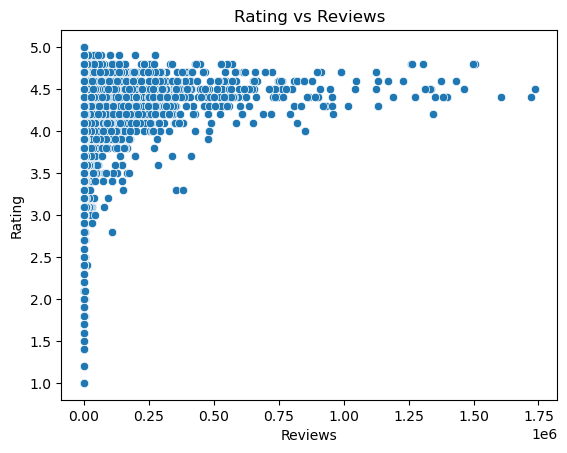

In [35]:
sns.scatterplot(x='Reviews', y='Rating', data=df)
plt.title("Rating vs Reviews")
plt.show()

#### 🔹 Boxplot Content Rating

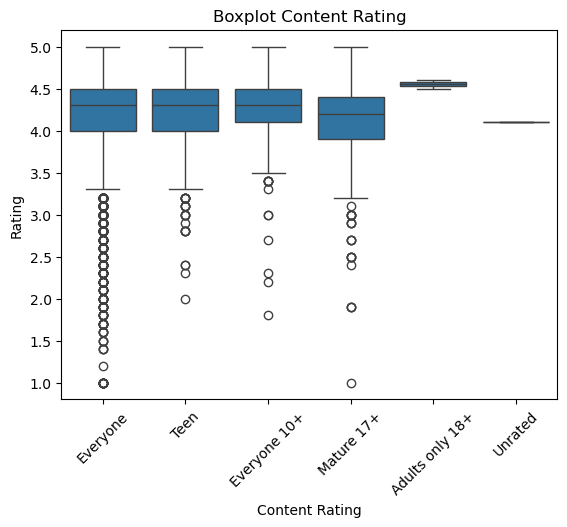

In [36]:
sns.boxplot(x='Content Rating', y='Rating', data=df)
plt.xticks(rotation=45)
plt.title("Boxplot Content Rating")
plt.show()

#### 🔹 Boxplot Category

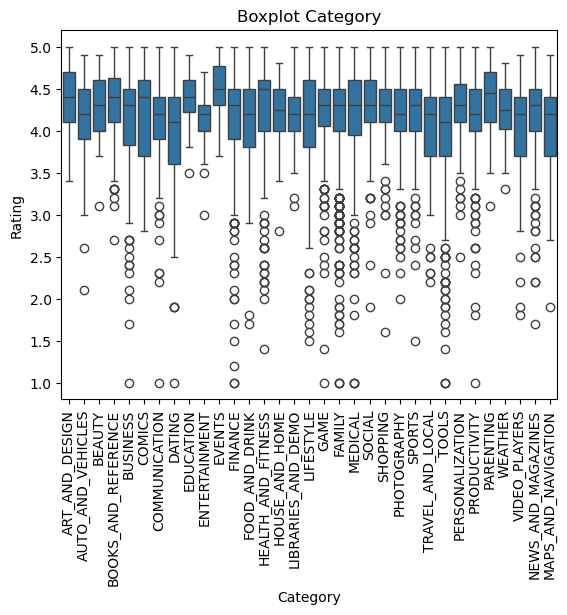

In [37]:
sns.boxplot(x='Category', y='Rating', data=df)
plt.xticks(rotation=90)
plt.title("Boxplot Category")
plt.show()

## ⚙️ STEP 9: Data Preprocessing

In [38]:
# Copy dataframe
inp1 = df.copy()

#### 🔹 Log Transformation

In [39]:
# Applying log transformation to reduce skewness
inp1['Reviews'] = np.log1p(inp1['Reviews'])
inp1['Installs'] = np.log1p(inp1['Installs'])

#### 🔹 Drop Columns

In [40]:
# Drop unnecessary columns
inp1.drop(['App', 'Last Updated', 'Current Ver', 'Android Ver'], axis=1, inplace=True)

#### 🔹 Dummy Encoding

In [41]:
# Create dummy columns (One-Hot Encoding)
inp2 = pd.get_dummies(inp1, columns=['Category', 'Genres', 'Content Rating'], drop_first=True)

## 📊 STEP 10: Train Test Split

In [44]:
df_train, df_test = train_test_split(inp2, test_size=0.3, random_state=42)

## 📌 STEP 11: X and y

In [45]:
X_train = df_train.drop('Rating', axis=1)
y_train = df_train['Rating']

X_test = df_test.drop('Rating', axis=1)
y_test = df_test['Rating']

## 🤖 STEP 12: Model Building

In [57]:
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

#Model Building - Linear Regression
model.fit(X_train, y_train)

# R2 score on train set
train_pred = model.predict(X_train)
r2_train = r2_score(y_train, train_pred)

print("Train R2 Score:", r2_train)

Train R2 Score: 0.16036440979501387


## 📊 STEP 13: Test Prediction

In [58]:
# Test prediction
test_pred = model.predict(X_test)

# Test R2 score
r2_test = r2_score(y_test, test_pred)

print("Test R2 Score:", r2_test)

Test R2 Score: 0.11349269132011874


Conclusion:
This model helps predict app ratings based on various features. 
Further improvements can be done using advanced models.